# FinWise Lending - Credit Risk Scoring with Explainability

## Project Overview
Build a credit risk scoring system with explainability using XGBoost and SHAP.

**Acceptance Criteria:**
- Gini coefficient >= 0.45 on test set
- SHAP waterfall chart rendered per prediction
- React UI displays score band (low/medium/high)
- API handles 50 concurrent requests
- Bias audit across gender/age reported

## 1. Setup and Imports

In [1]:
# Install required packages (uncomment if needed)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap fastapi uvicorn mlflow jupyter jupytext

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# SHAP
import shap

# Display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 528.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 2. Load and Explore the Data

In [2]:
# Load the data
df = pd.read_csv('/content/finwise_loan_applications.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (1000, 13)

Column Names:
['application_id', 'age', 'income_annual_inr', 'employment_type', 'employment_years', 'existing_loans', 'existing_emi_inr', 'credit_score', 'loan_amount_inr', 'loan_purpose', 'ltv_ratio', 'dti_ratio', 'default_flag']

Data Types:
application_id        object
age                    int64
income_annual_inr      int64
employment_type       object
employment_years       int64
existing_loans         int64
existing_emi_inr       int64
credit_score           int64
loan_amount_inr        int64
loan_purpose          object
ltv_ratio            float64
dti_ratio            float64
default_flag           int64
dtype: object

First 5 rows:


,application_id,age,income_annual_inr,employment_type,employment_years,existing_loans,existing_emi_inr,credit_score,loan_amount_inr,loan_purpose,ltv_ratio,dti_ratio,default_flag
0,APP-0001,47,840000,self_employed,20,1,6772,681,500000,medical,0.61,0.15,0
1,APP-0002,56,300000,contract,7,3,44496,815,2500000,personal,0.52,2.58,1
2,APP-0003,45,2400000,contract,7,1,10560,596,500000,home,0.92,0.07,0
3,APP-0004,27,840000,government,13,0,0,548,2500000,home,0.63,0.29,0
4,APP-0005,56,300000,contract,17,1,12920,654,250000,vehicle,0.92,0.60,0


In [3]:
# Basic statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal Applications: {len(df):,}")
print(f"Default Rate: {df['default_flag'].mean():.2%}")
print(f"Non-Default: {(df['default_flag'] == 0).sum():,}")
print(f"Default: {(df['default_flag'] == 1).sum():,}")

DATASET OVERVIEW

Total Applications: 1,000
Default Rate: 23.80%
Non-Default: 762
Default: 238


In [4]:
# Check for missing values
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


Missing Values:
No missing values found!


In [5]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,4.069200e+01,1.074377e+01,22.0,31.75,41.00,50.00,58.00
income_annual_inr,1000.0,1.093800e+06,7.256512e+05,300000.0,420000.00,840000.00,1800000.00,2400000.00
employment_years,1000.0,1.079200e+01,5.725515e+00,1.0,6.00,11.00,16.00,20.00
existing_loans,1000.0,1.516000e+00,1.090382e+00,0.0,1.00,2.00,2.00,3.00
existing_emi_inr,1000.0,1.384952e+04,1.188737e+04,0.0,4310.25,11959.50,21749.25,44976.00
credit_score,1000.0,6.814910e+02,7.915220e+01,453.0,628.00,680.00,736.00,900.00
loan_amount_inr,1000.0,1.585900e+06,1.732011e+06,100000.0,250000.00,1000000.00,2500000.00,5000000.00
ltv_ratio,1000.0,6.698300e-01,1.565899e-01,0.4,0.54,0.66,0.80,0.95
dti_ratio,1000.0,4.668000e-01,4.824144e-01,0.0,0.13,0.30,0.64,3.06
default_flag,1000.0,2.380000e-01,4.260722e-01,0.0,0.00,0.00,0.00,1.00


In [6]:
# Categorical columns analysis
cat_cols = ['employment_type', 'loan_purpose']

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col.upper()} Distribution")
    print(f"{'='*50}")
    print(df[col].value_counts())
    print(f"\nDefault rate by {col}:")
    print(df.groupby(col)['default_flag'].agg(['mean', 'count']).round(4))


EMPLOYMENT_TYPE Distribution
employment_type
government       262
self_employed    261
contract         247
salaried         230
Name: count, dtype: int64

Default rate by employment_type:
                   mean  count
employment_type               
contract         0.1741    247
government       0.2557    262
salaried         0.2913    230
self_employed    0.2337    261

LOAN_PURPOSE Distribution
loan_purpose
personal     201
vehicle      173
home         166
education    160
medical      156
business     144
Name: count, dtype: int64

Default rate by loan_purpose:
                mean  count
loan_purpose               
business      0.2500    144
education     0.2312    160
home          0.2530    166
medical       0.2500    156
personal      0.2139    201
vehicle       0.2370    173


## 3. Exploratory Data Analysis (EDA)

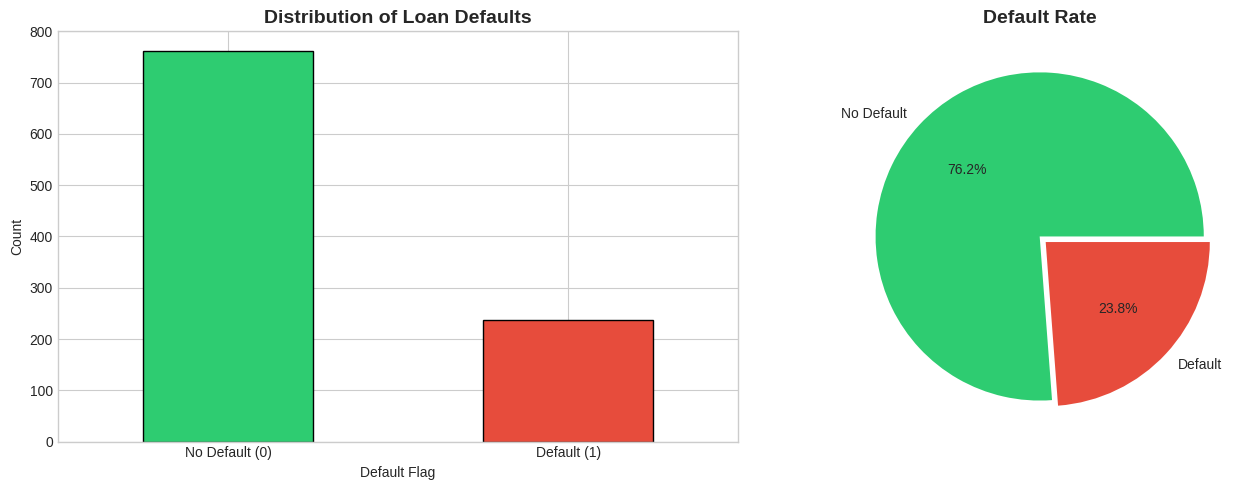

In [7]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
df['default_flag'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Loan Defaults', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default Flag')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

df['default_flag'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                        colors=colors, explode=[0, 0.05],
                                        labels=['No Default', 'Default'])
axes[1].set_title('Default Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

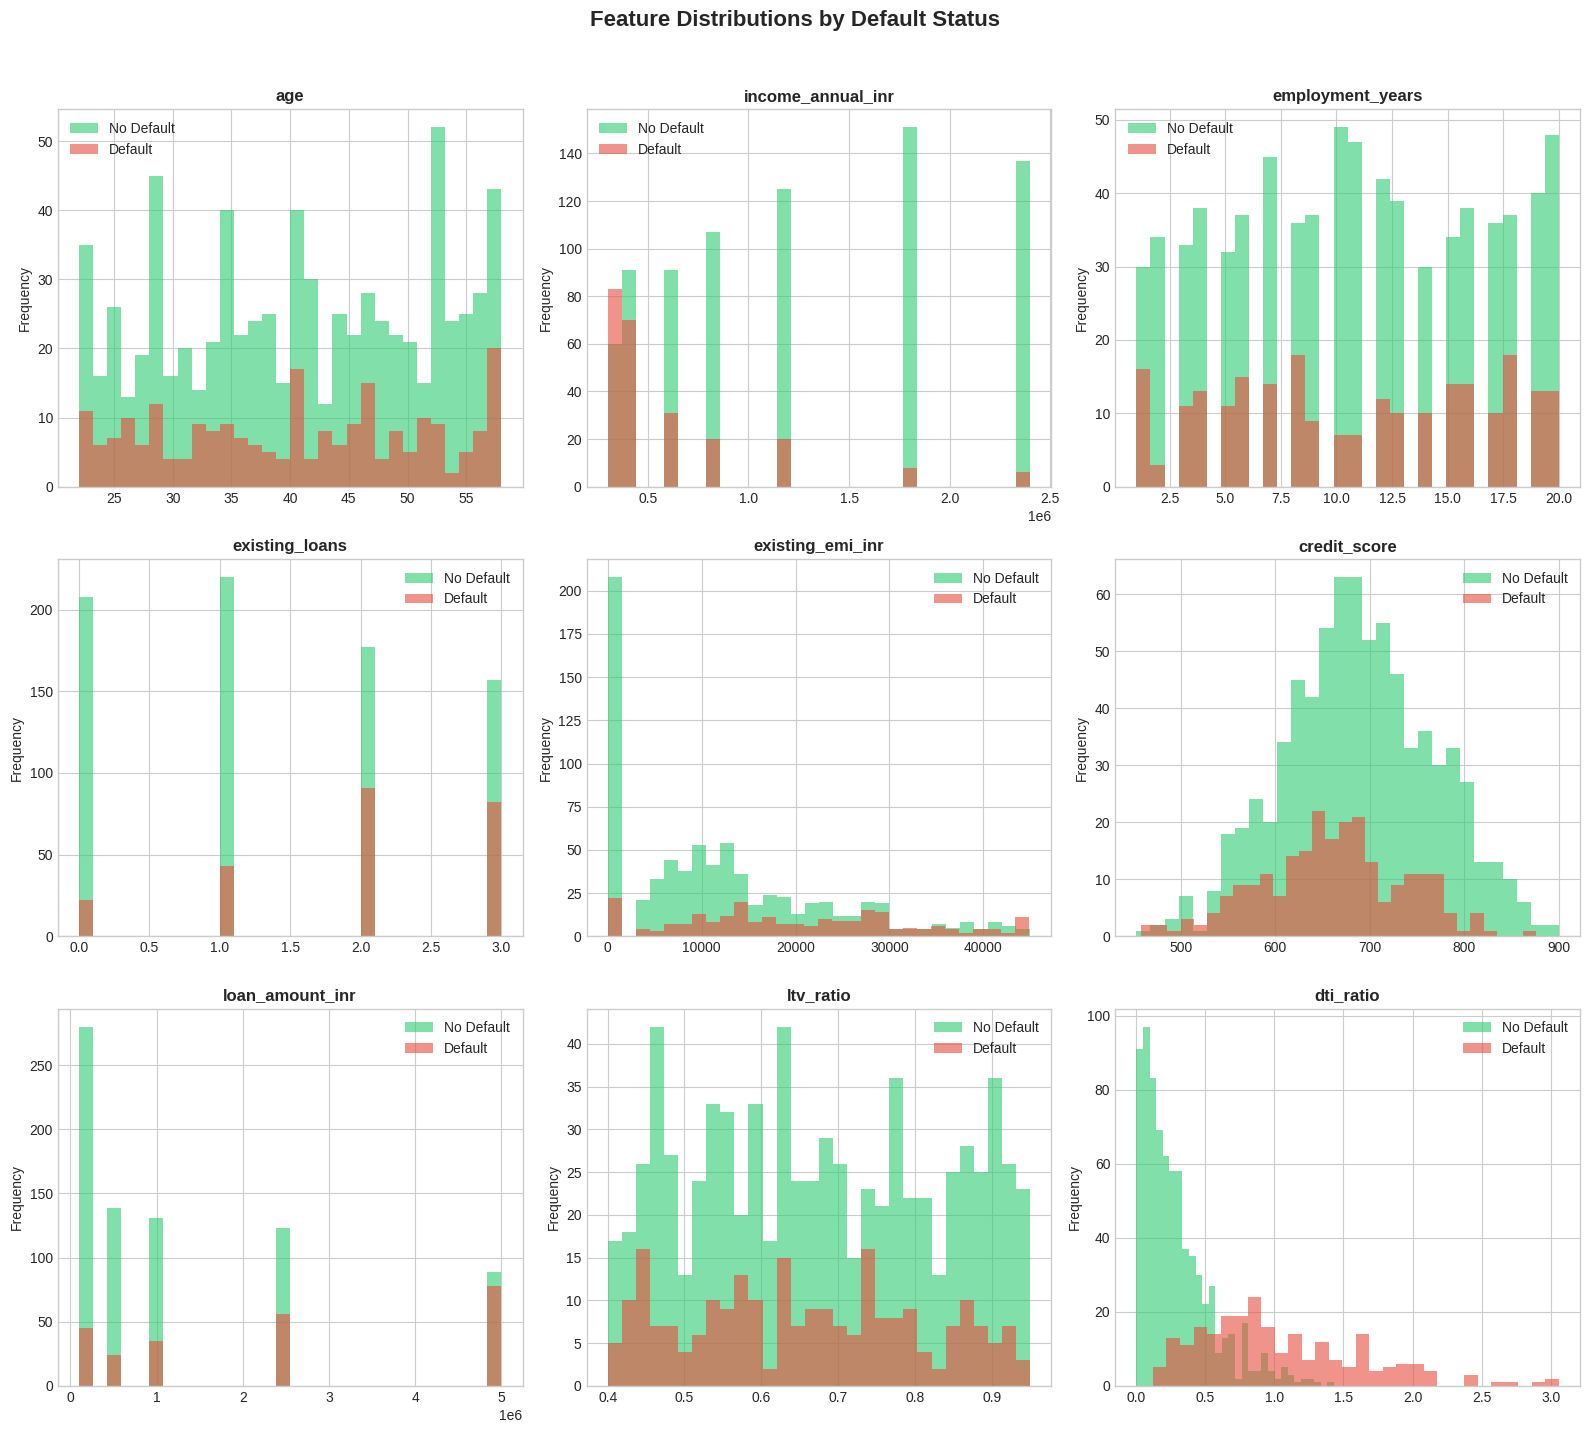

In [8]:
# Numerical features distribution
num_cols = ['age', 'income_annual_inr', 'employment_years', 'existing_loans',
            'existing_emi_inr', 'credit_score', 'loan_amount_inr', 'ltv_ratio', 'dti_ratio']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df[df['default_flag'] == 0][col].hist(ax=ax, bins=30, alpha=0.6, label='No Default', color='#2ecc71')
    df[df['default_flag'] == 1][col].hist(ax=ax, bins=30, alpha=0.6, label='Default', color='#e74c3c')
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Default Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

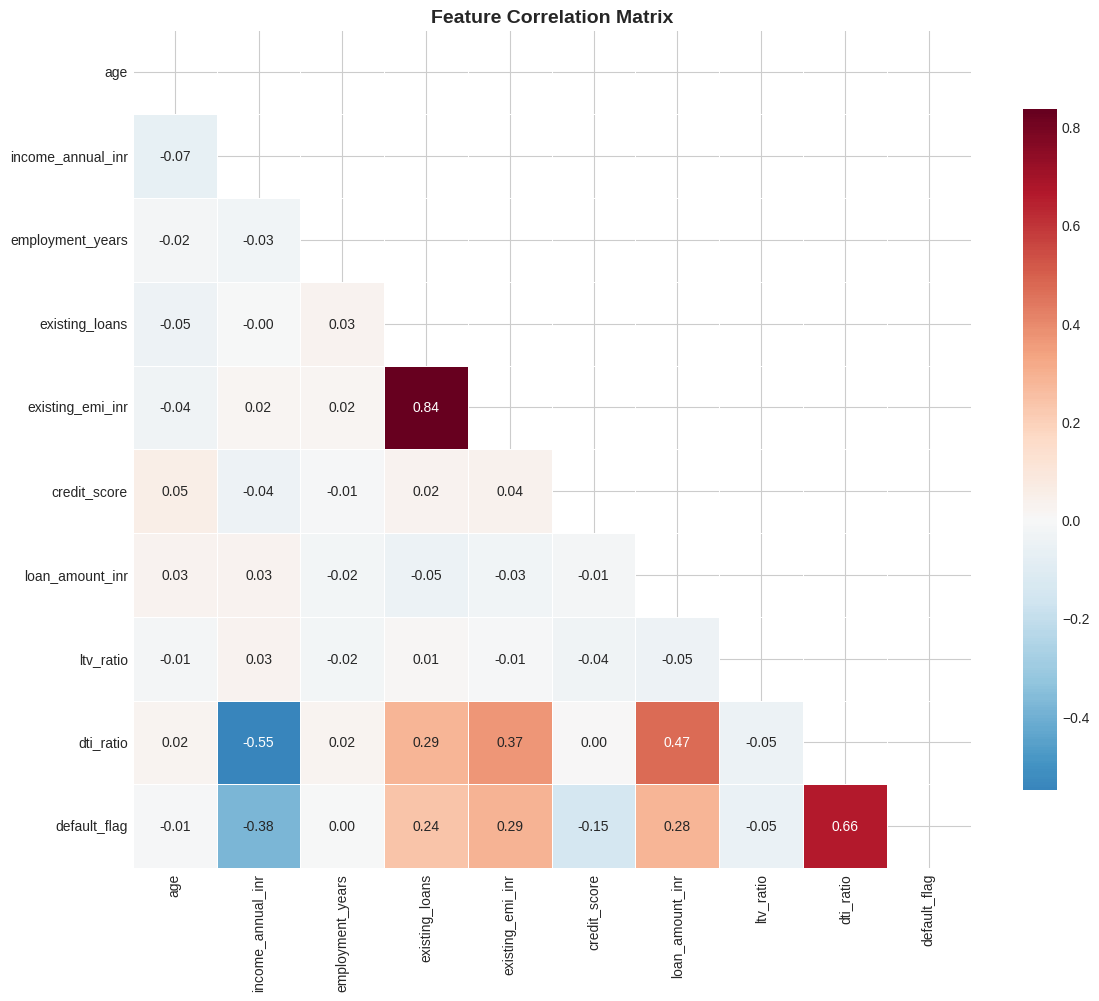

In [9]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))

corr_cols = num_cols + ['default_flag']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

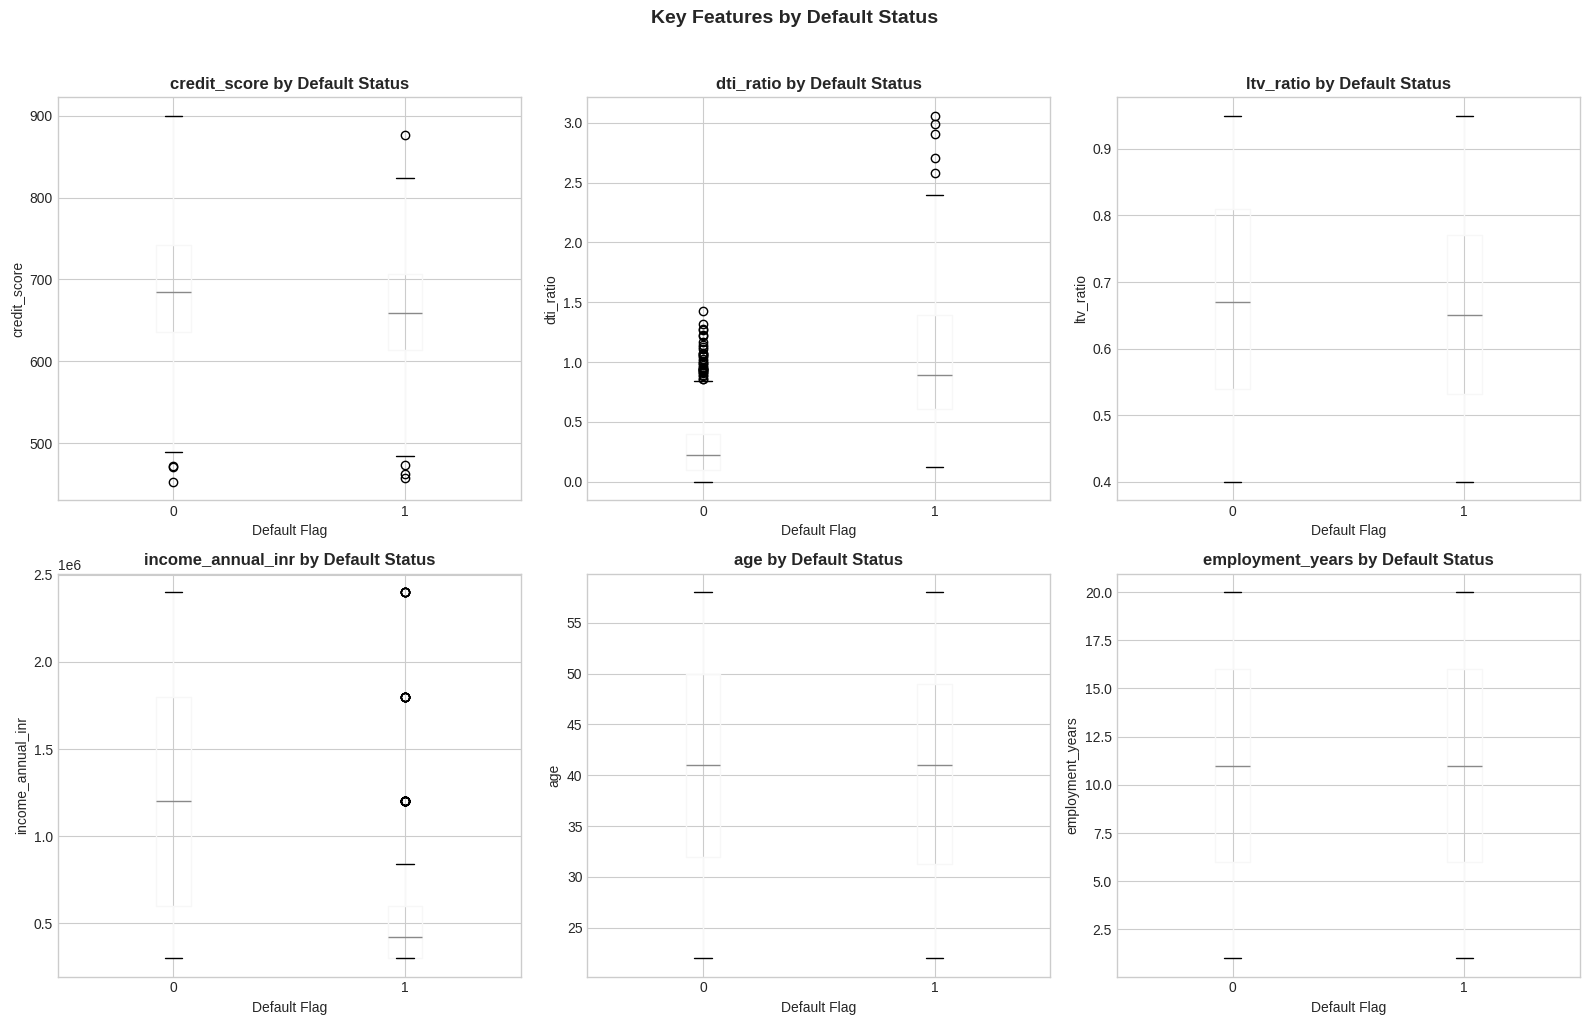

In [10]:
# Box plots for key features by default status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['credit_score', 'dti_ratio', 'ltv_ratio', 'income_annual_inr', 'age', 'employment_years']

for i, col in enumerate(key_features):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=col, by='default_flag', ax=ax)
    ax.set_title(f'{col} by Default Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Default Flag')
    ax.set_ylabel(col)

plt.suptitle('Key Features by Default Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

In [11]:
df_fe = df.copy()

df_fe['emi_to_income_ratio'] = df_fe['existing_emi_inr'] / (df_fe['income_annual_inr'] / 12 + 1)
df_fe['emi_to_income_ratio'] = df_fe['emi_to_income_ratio'].clip(0, 10)

df_fe['loan_to_income_ratio'] = df_fe['loan_amount_inr'] / (df_fe['income_annual_inr'] + 1)

df_fe['total_debt'] = df_fe['existing_emi_inr'] * 12 + df_fe['loan_amount_inr']
df_fe['debt_to_income'] = df_fe['total_debt'] / (df_fe['income_annual_inr'] + 1)

df_fe['credit_score_band'] = pd.cut(df_fe['credit_score'],
                                     bins=[0, 580, 670, 740, 800, 900],
                                     labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

df_fe['age_group'] = pd.cut(df_fe['age'],
                             bins=[0, 30, 40, 50, 60, 100],
                             labels=['Young', 'Early Career', 'Mid Career', 'Senior', 'Elder'])

df_fe['employment_stability'] = df_fe['employment_years'] / (df_fe['age'] - 17 + 1)

df_fe['high_dti'] = (df_fe['dti_ratio'] > 0.5).astype(int)
df_fe['high_ltv'] = (df_fe['ltv_ratio'] > 0.8).astype(int)
df_fe['low_credit'] = (df_fe['credit_score'] < 600).astype(int)
df_fe['multiple_loans'] = (df_fe['existing_loans'] >= 2).astype(int)

df_fe['risk_score'] = (df_fe['high_dti'] + df_fe['high_ltv'] +
                        df_fe['low_credit'] + df_fe['multiple_loans'])

print("New features created:")
new_features = ['emi_to_income_ratio', 'loan_to_income_ratio', 'debt_to_income',
                'credit_score_band', 'age_group', 'employment_stability',
                'high_dti', 'high_ltv', 'low_credit', 'multiple_loans', 'risk_score']
print(new_features)

New features created:
['emi_to_income_ratio', 'loan_to_income_ratio', 'debt_to_income', 'credit_score_band', 'age_group', 'employment_stability', 'high_dti', 'high_ltv', 'low_credit', 'multiple_loans', 'risk_score']


In [12]:
df_fe[new_features].describe()

,emi_to_income_ratio,loan_to_income_ratio,debt_to_income,employment_stability,high_dti,high_ltv,low_credit,multiple_loans,risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.243385,2.328509,2.571900,0.582654,0.321000,0.24300,0.152000,0.507000,1.223000
std,0.293154,3.467536,3.533200,0.528251,0.467094,0.42911,0.359201,0.500201,0.926353
min,0.000000,0.041667,0.041667,0.023810,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.030525,0.277778,0.470158,0.230769,0.000000,0.00000,0.000000,0.000000,1.000000
50%,0.147324,0.833333,1.190473,0.437500,0.000000,0.00000,0.000000,1.000000,1.000000
75%,0.343833,2.777776,2.909819,0.734211,1.000000,0.00000,0.000000,1.000000,2.000000
max,1.780129,16.666611,18.124246,3.333333,1.000000,1.00000,1.000000,1.000000,4.000000


In [13]:
print("\nDefault Rate by Credit Score Band:")
print(df_fe.groupby('credit_score_band', observed=True)['default_flag'].agg(['mean', 'count']).round(4))

print("\nDefault Rate by Risk Score:")
print(df_fe.groupby('risk_score')['default_flag'].agg(['mean', 'count']).round(4))


Default Rate by Credit Score Band:
                     mean  count
credit_score_band               
Poor               0.3431    102
Fair               0.2787    348
Good               0.2025    316
Very Good          0.2134    164
Excellent          0.1000     70

Default Rate by Risk Score:
              mean  count
risk_score               
0           0.0083    241
1           0.1641    384
2           0.4329    298
3           0.5385     65
4           0.7500     12


## 5. Data Preprocessing

In [14]:
drop_cols = ['application_id', 'default_flag']

le_dict = {}
df_model = df_fe.copy()

cat_features = ['employment_type', 'loan_purpose', 'credit_score_band', 'age_group']

for col in cat_features:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        drop_cols.append(col)

drop_cols = list(set(drop_cols))
X = df_model.drop(columns=drop_cols)
y = df_model['default_flag']

X = X.select_dtypes(include=[np.number])

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"\nFeatures used for modeling:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Feature Matrix Shape: (1000, 23)
Target Shape: (1000,)

Features used for modeling:
  1. age
  2. income_annual_inr
  3. employment_years
  4. existing_loans
  5. existing_emi_inr
  6. credit_score
  7. loan_amount_inr
  8. ltv_ratio
  9. dti_ratio
  10. emi_to_income_ratio
  11. loan_to_income_ratio
  12. total_debt
  13. debt_to_income
  14. employment_stability
  15. high_dti
  16. high_ltv
  17. low_credit
  18. multiple_loans
  19. risk_score
  20. employment_type_encoded
  21. loan_purpose_encoded
  22. credit_score_band_encoded
  23. age_group_encoded


In [15]:
print("\nData types in feature matrix:")
print(X.dtypes.value_counts())

print(f"\nAny missing values: {X.isnull().sum().sum()}")
print(f"Any infinite values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

X = X.replace([np.inf, -np.inf], 0)


Data types in feature matrix:
int64      17
float64     6
Name: count, dtype: int64

Any missing values: 0
Any infinite values: 0


## 6. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 50)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining set default rate: {y_train.mean():.2%}")
print(f"Test set default rate: {y_test.mean():.2%}")

TRAIN-TEST SPLIT SUMMARY
Training set size: 800 (80.0%)
Test set size: 200 (20.0%)

Training set default rate: 23.75%
Test set default rate: 24.00%


In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale Pos Weight: {scale_pos_weight:.2f}")


Scale Pos Weight: 3.21


## 7. Model Training - XGBoost

In [18]:
xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'eval_metric': 'auc',
}

model = XGBClassifier(**xgb_params)

evals = [(X_train, y_train), (X_test, y_test)]

model.fit(
    X_train, y_train,
    eval_set=evals,
    verbose=50
)

print("\nModel training complete!")

[0]	validation_0-auc:0.92993	validation_1-auc:0.85917
[50]	validation_0-auc:0.98303	validation_1-auc:0.89405
[100]	validation_0-auc:0.99296	validation_1-auc:0.89542
[150]	validation_0-auc:0.99739	validation_1-auc:0.89145
[200]	validation_0-auc:0.99912	validation_1-auc:0.89008
[250]	validation_0-auc:0.99988	validation_1-auc:0.88967
[300]	validation_0-auc:0.99997	validation_1-auc:0.89049
[350]	validation_0-auc:0.99999	validation_1-auc:0.88734
[400]	validation_0-auc:1.00000	validation_1-auc:0.88816
[450]	validation_0-auc:1.00000	validation_1-auc:0.88542
[499]	validation_0-auc:1.00000	validation_1-auc:0.88418

Model training complete!


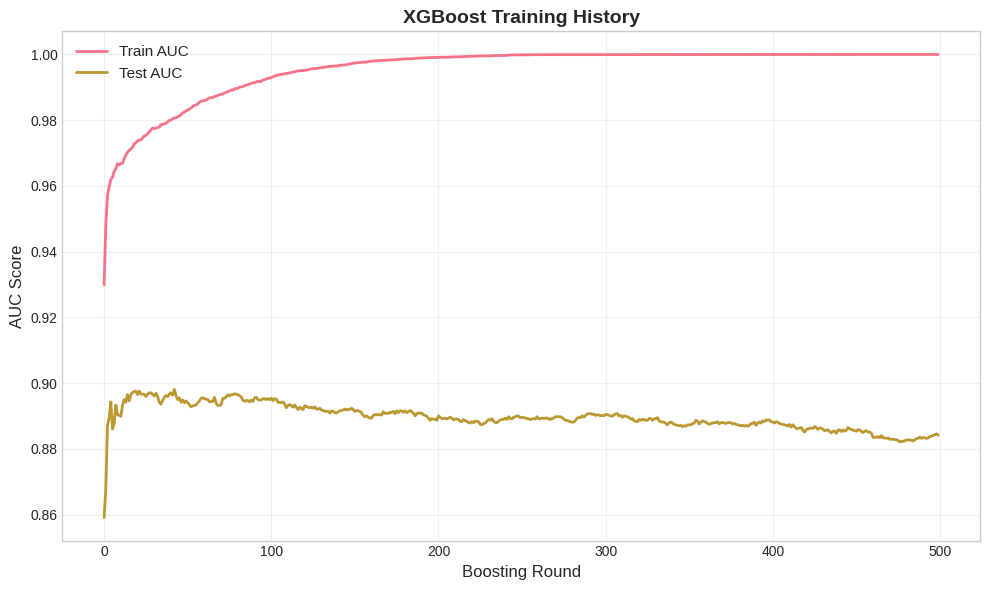

In [19]:
results = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results['validation_0']['auc'], label='Train AUC', linewidth=2)
ax.plot(results['validation_1']['auc'], label='Test AUC', linewidth=2)
ax.set_xlabel('Boosting Round', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('XGBoost Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation

In [20]:
y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [21]:
def gini_coefficient(y_true, y_pred_proba):
    """Calculate Gini coefficient from AUC"""
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    return gini, auc

train_gini, train_auc = gini_coefficient(y_train, y_train_pred_proba)
test_gini, test_auc = gini_coefficient(y_test, y_test_pred_proba)

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"\n{'Metric':<25} {'Train':<15} {'Test':<15}")
print("-" * 55)
print(f"{'AUC-ROC':<25} {train_auc:<15.4f} {test_auc:<15.4f}")
print(f"{'Gini Coefficient':<25} {train_gini:<15.4f} {test_gini:<15.4f}")

print(f"\n{'='*60}")
print("ACCEPTANCE CRITERIA CHECK")
print(f"{'='*60}")
print(f"Gini coefficient >= 0.45 on test set: {'PASSED' if test_gini >= 0.45 else 'FAILED'}")
print(f"  Test Gini: {test_gini:.4f}")

MODEL PERFORMANCE METRICS

Metric                    Train           Test           
-------------------------------------------------------
AUC-ROC                   1.0000          0.8842         
Gini Coefficient          1.0000          0.7684         

ACCEPTANCE CRITERIA CHECK
Gini coefficient >= 0.45 on test set: PASSED
  Test Gini: 0.7684


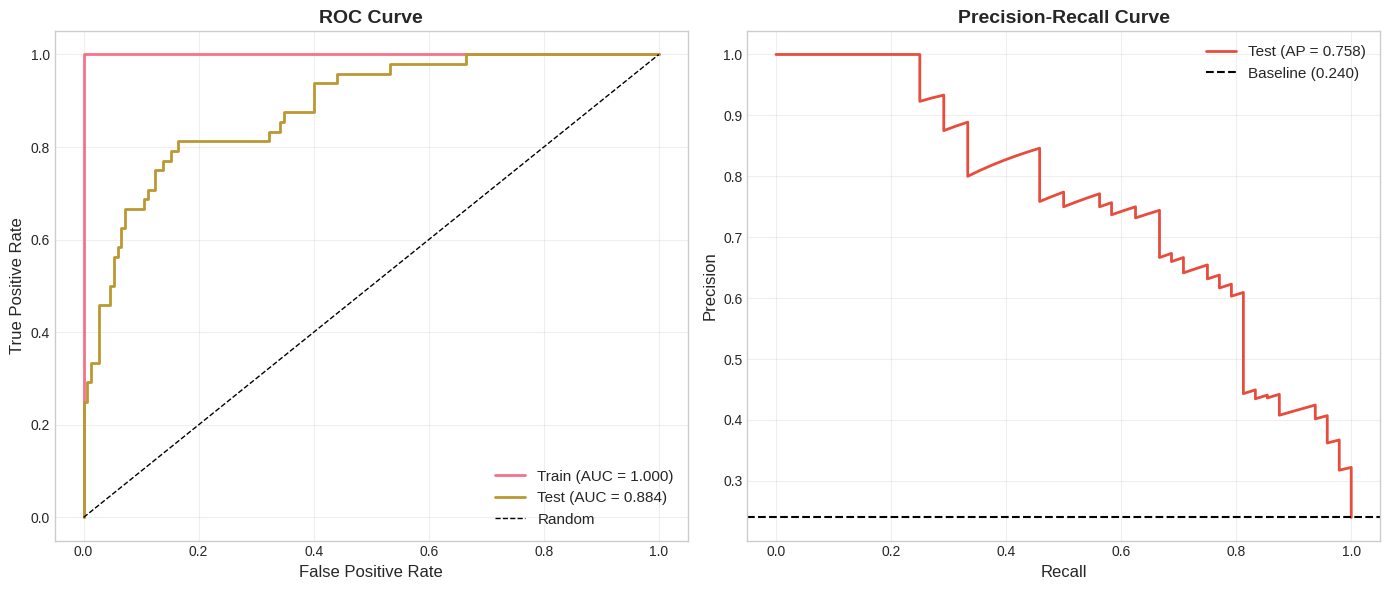

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

ax.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_auc:.3f})', linewidth=2)
ax.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_pred_proba)
avg_precision = average_precision_score(y_test, y_test_pred_proba)

ax.plot(recall_test, precision_test, label=f'Test (AP = {avg_precision:.3f})', linewidth=2, color='#e74c3c')
ax.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 NEW: KS Statistic Plot (Train vs Test separation power)

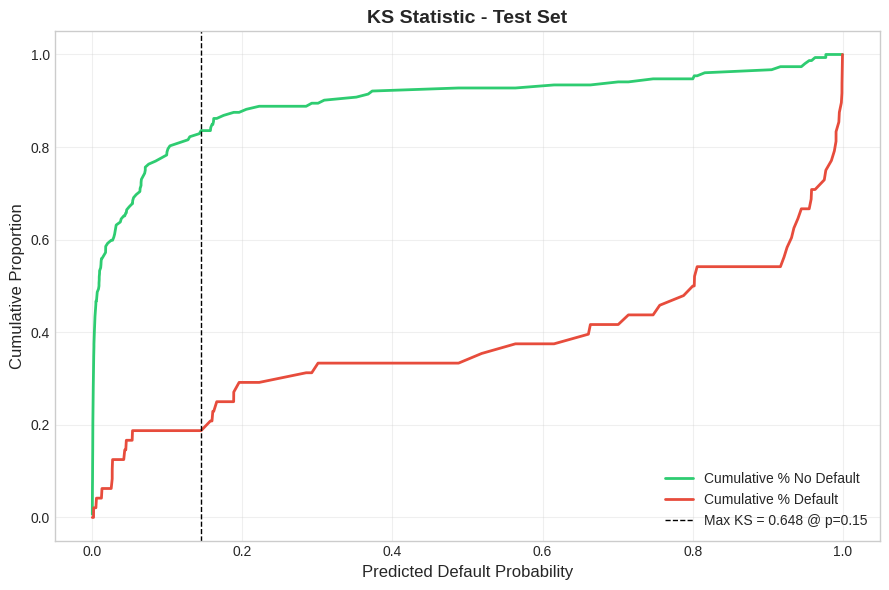

KS Statistic (Test Set): 0.6480  (>0.3 is generally considered acceptable in credit risk)


In [23]:
# Kolmogorov-Smirnov (KS) plot - a standard credit risk metric showing how well
# the model separates "default" vs "no default" cumulative distributions.
def ks_stat_plot(y_true, y_pred_proba, title='KS Statistic'):
    df_ks = pd.DataFrame({'y': y_true, 'p': y_pred_proba}).sort_values('p')
    df_ks['cum_good'] = (1 - df_ks['y']).cumsum() / (1 - df_ks['y']).sum()
    df_ks['cum_bad'] = df_ks['y'].cumsum() / df_ks['y'].sum()
    df_ks['ks'] = (df_ks['cum_bad'] - df_ks['cum_good']).abs()
    ks_value = df_ks['ks'].max()
    ks_at = df_ks.loc[df_ks['ks'].idxmax(), 'p']

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(df_ks['p'], df_ks['cum_good'], label='Cumulative % No Default', color='#2ecc71', linewidth=2)
    ax.plot(df_ks['p'], df_ks['cum_bad'], label='Cumulative % Default', color='#e74c3c', linewidth=2)
    ax.axvline(ks_at, color='black', linestyle='--', linewidth=1,
               label=f'Max KS = {ks_value:.3f} @ p={ks_at:.2f}')
    ax.set_xlabel('Predicted Default Probability', fontsize=12)
    ax.set_ylabel('Cumulative Proportion', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ks_value

fig, ks_value = ks_stat_plot(y_test.values, y_test_pred_proba, title='KS Statistic - Test Set')
plt.savefig('ks_statistic.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"KS Statistic (Test Set): {ks_value:.4f}  (>0.3 is generally considered acceptable in credit risk)")

### 8.2 NEW: Calibration Curve (Reliability Diagram)

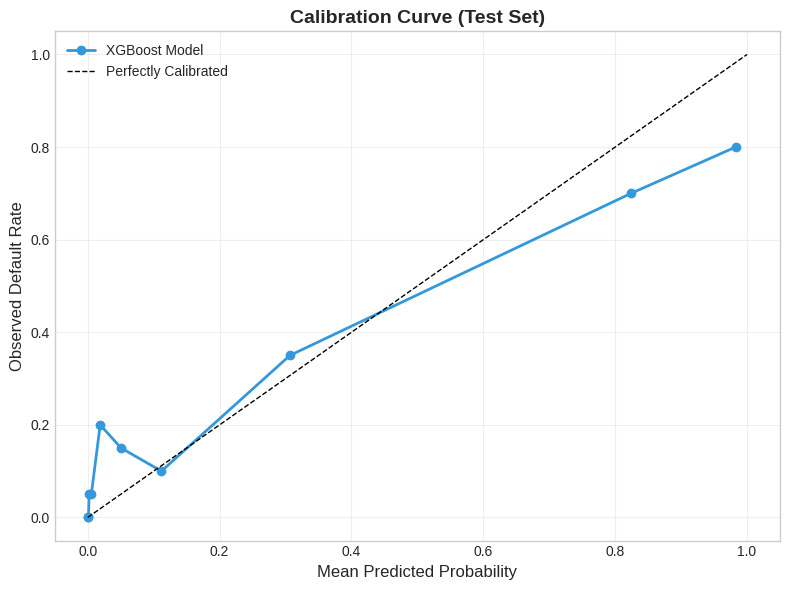

In [24]:
# Shows whether predicted probabilities match observed default rates -
# important for a risk model whose scores drive real lending decisions.
prob_true, prob_pred = calibration_curve(y_test, y_test_pred_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(prob_pred, prob_true, marker='o', linewidth=2, color='#3498db', label='XGBoost Model')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Default Rate', fontsize=12)
ax.set_title('Calibration Curve (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 NEW: Lift / Gains Chart

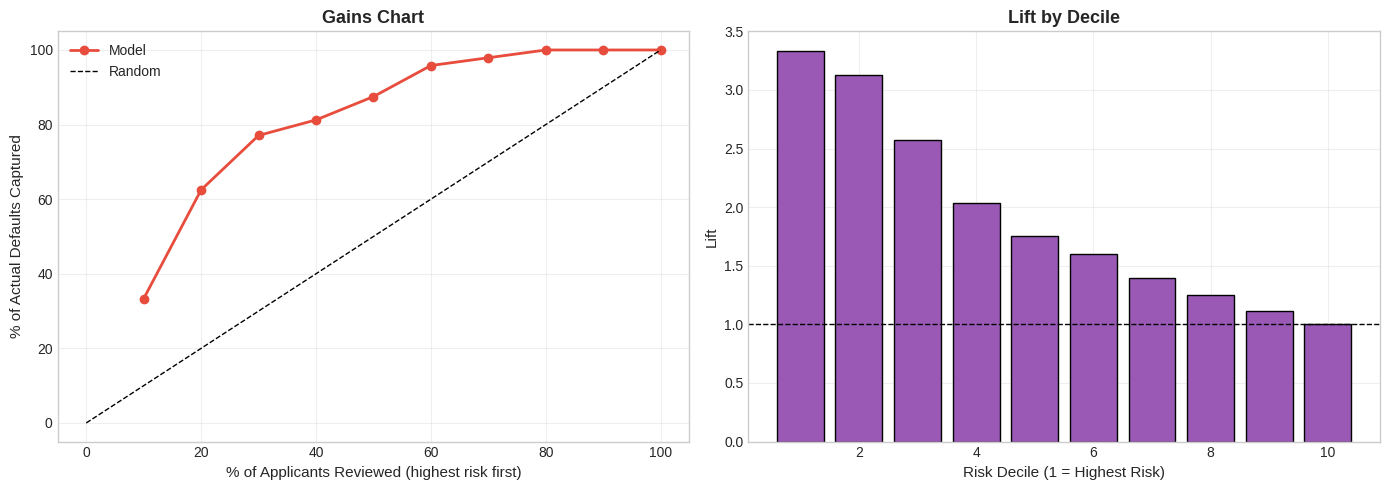

        total  defaults  cum_defaults  cum_pct_defaults  cum_pct_population  \
decile                                                                        
1          20        16            16             0.333                 0.1   
2          20        14            30             0.625                 0.2   
3          20         7            37             0.771                 0.3   
4          20         2            39             0.812                 0.4   
5          20         3            42             0.875                 0.5   
6          20         4            46             0.958                 0.6   
7          20         1            47             0.979                 0.7   
8          20         1            48             1.000                 0.8   
9          20         0            48             1.000                 0.9   
10         20         0            48             1.000                 1.0   

         lift  
decile         
1       3.333  
2  

In [25]:
# Lift chart: if you rank applicants by predicted risk and decline the riskiest
# decile, how many actual defaults do you catch compared to random selection?
def lift_gains_chart(y_true, y_pred_proba, n_bins=10):
    df_l = pd.DataFrame({'y': y_true, 'p': y_pred_proba})
    df_l['decile'] = pd.qcut(df_l['p'].rank(method='first'), n_bins, labels=False) + 1
    df_l['decile'] = n_bins + 1 - df_l['decile']  # decile 1 = highest risk

    agg = df_l.groupby('decile').agg(total=('y', 'size'), defaults=('y', 'sum')).sort_index()
    agg['cum_defaults'] = agg['defaults'].cumsum()
    agg['cum_pct_defaults'] = agg['cum_defaults'] / agg['defaults'].sum()
    agg['cum_pct_population'] = agg['total'].cumsum() / agg['total'].sum()
    agg['lift'] = agg['cum_pct_defaults'] / agg['cum_pct_population']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(agg['cum_pct_population'] * 100, agg['cum_pct_defaults'] * 100,
            marker='o', linewidth=2, color='#e74c3c', label='Model')
    ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random')
    ax.set_xlabel('% of Applicants Reviewed (highest risk first)', fontsize=11)
    ax.set_ylabel('% of Actual Defaults Captured', fontsize=11)
    ax.set_title('Gains Chart', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(agg.index, agg['lift'], color='#9b59b6', edgecolor='black')
    ax.axhline(1, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel('Risk Decile (1 = Highest Risk)', fontsize=11)
    ax.set_ylabel('Lift', fontsize=11)
    ax.set_title('Lift by Decile', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, agg

fig, lift_table = lift_gains_chart(y_test.values, y_test_pred_proba)
plt.savefig('lift_gains_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(lift_table.round(3))

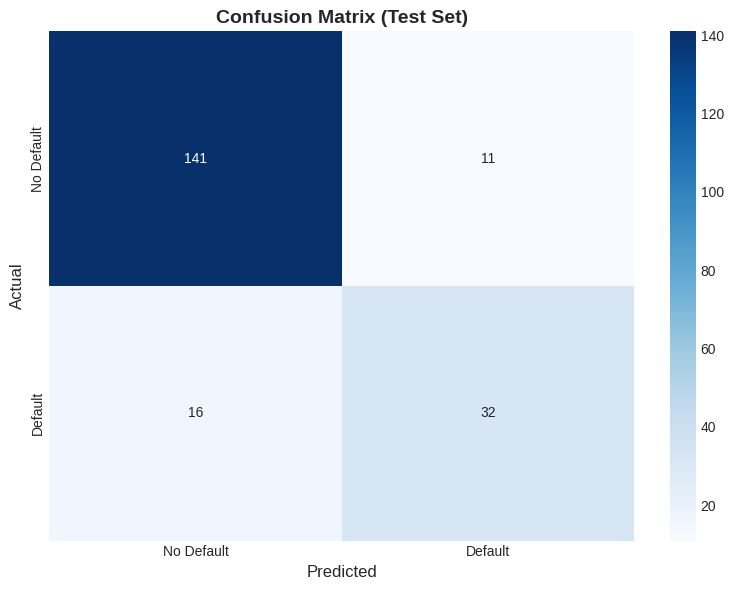

In [26]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("\nClassification Report (Test Set):")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))


Classification Report (Test Set):
              precision    recall  f1-score   support

  No Default       0.90      0.93      0.91       152
     Default       0.74      0.67      0.70        48

    accuracy                           0.86       200
   macro avg       0.82      0.80      0.81       200
weighted avg       0.86      0.86      0.86       200



In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"CV AUC Scores: {cv_scores}")
print(f"Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Mean Gini: {2 * cv_scores.mean() - 1:.4f}")

5-FOLD CROSS-VALIDATION RESULTS
CV AUC Scores: [0.87331386 0.90529829 0.88966557 0.85074013 0.9176261 ]
Mean AUC: 0.8873 (+/- 0.0472)
Mean Gini: 0.7747


## 9. Feature Importance

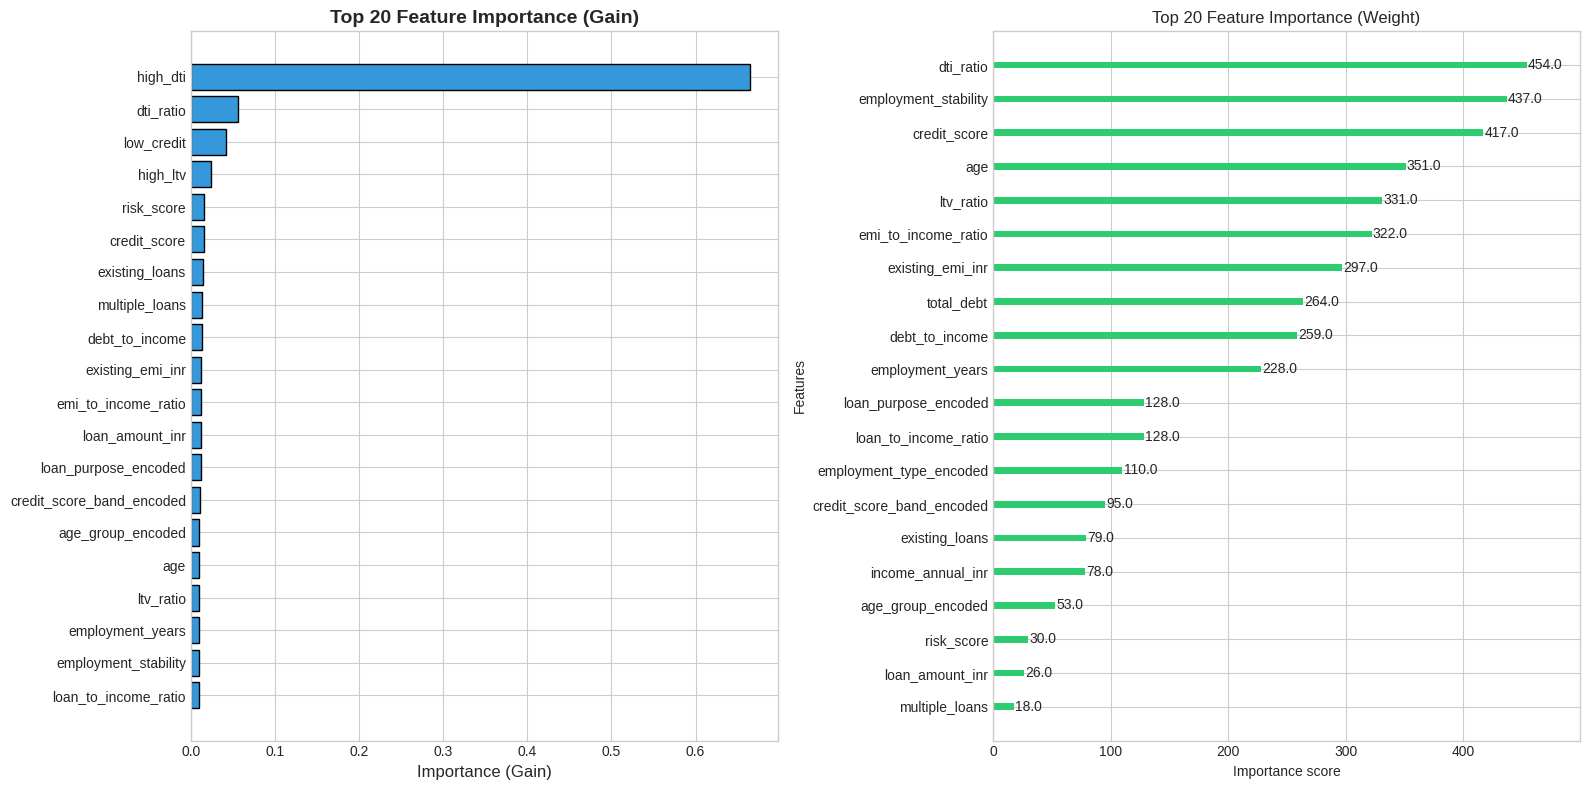

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

importance_gain = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importance_gain)[::-1][:20]

ax = axes[0]
ax.barh(range(len(indices)), importance_gain[indices], color='#3498db', edgecolor='black')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Feature Importance (Gain)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

from xgboost import plot_importance
plot_importance(model, ax=axes[1], max_num_features=20, importance_type='weight',
                color='#2ecc71', title='Top 20 Feature Importance (Weight)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. SHAP Explainability

In [30]:
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(model)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

Creating SHAP explainer...
Calculating SHAP values...
SHAP values shape: (200, 23)


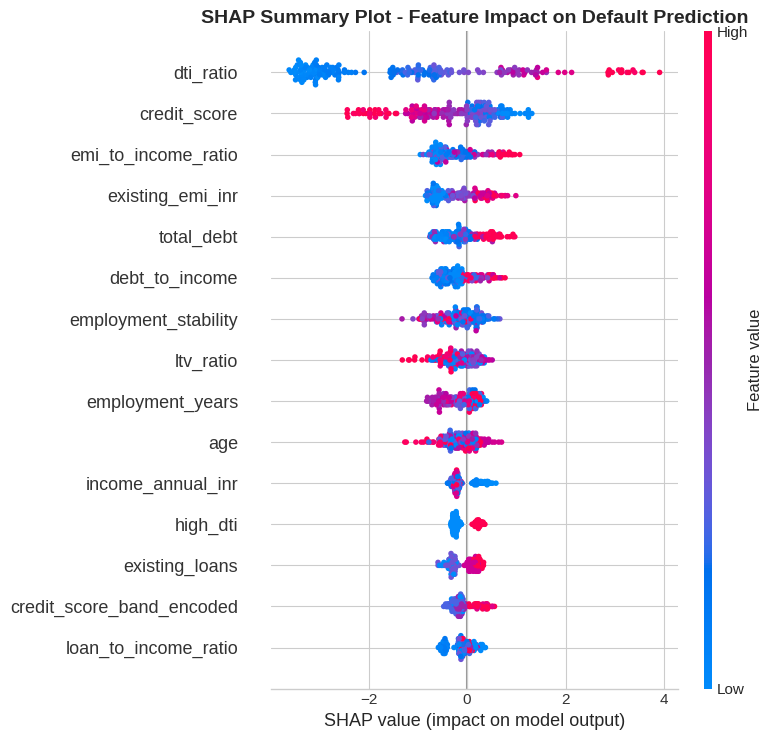

In [31]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False, max_display=15)
plt.title('SHAP Summary Plot - Feature Impact on Default Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

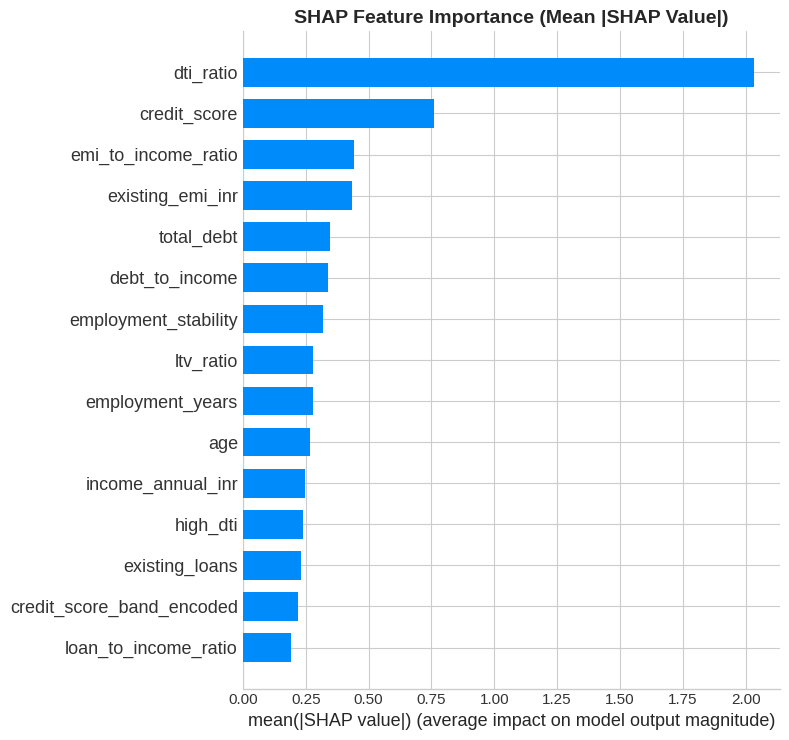

In [32]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

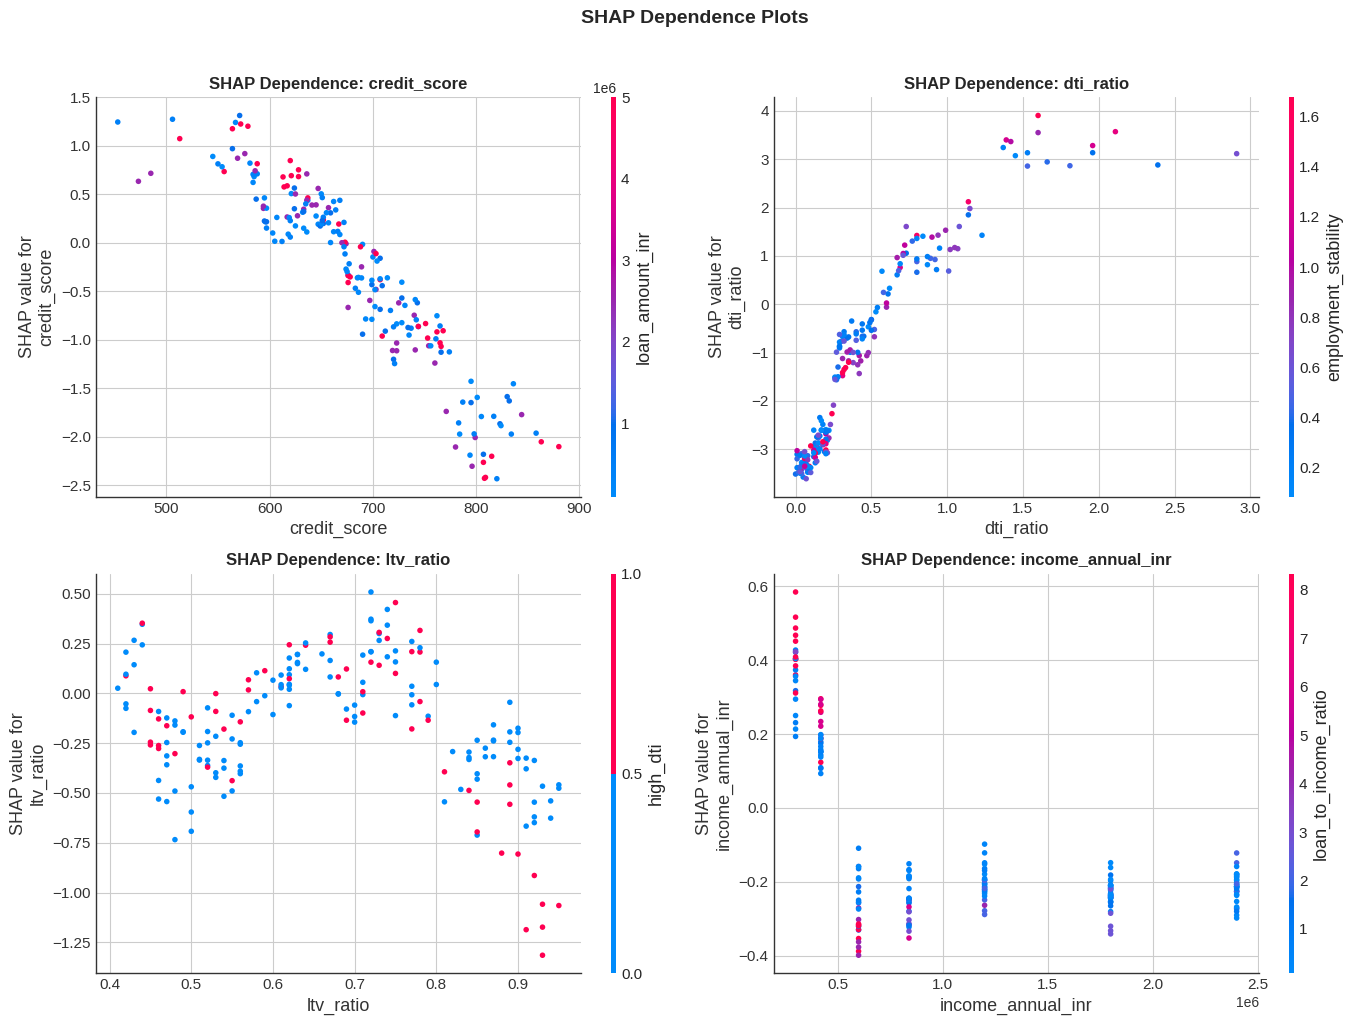

In [33]:
top_features = ['credit_score', 'dti_ratio', 'ltv_ratio', 'income_annual_inr']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if feature in X_test.columns:
        ax = axes[i]
        shap.dependence_plot(feature, shap_values, X_test, ax=ax, show=False)
        ax.set_title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')

plt.suptitle('SHAP Dependence Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Individual Prediction Explanation (Waterfall Chart)

In [34]:
def explain_prediction(applicant_idx, X_data, shap_vals, explainer, feature_names):
    applicant_data = X_data.iloc[applicant_idx]
    applicant_shap = shap_vals[applicant_idx]

    explanation = shap.Explanation(
        values=applicant_shap,
        base_values=explainer.expected_value,
        data=applicant_data.values,
        feature_names=feature_names
    )

    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'SHAP Waterfall Chart - Applicant {applicant_idx}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return plt.gcf()

INDIVIDUAL PREDICTION EXPLANATIONS

HIGH RISK APPLICANT (Index: 154)
   Default Probability: 99.96%
   Actual: Default


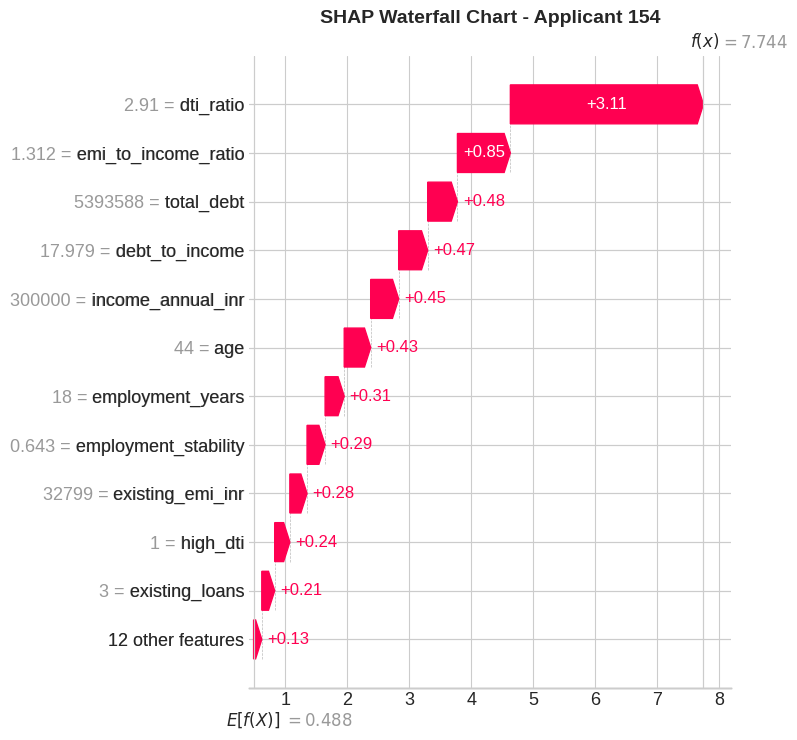

In [35]:
high_risk_idx = np.argmax(y_test_pred_proba)
low_risk_idx = np.argmin(y_test_pred_proba)
random_idx = np.random.randint(0, len(X_test))

print("=" * 60)
print("INDIVIDUAL PREDICTION EXPLANATIONS")
print("=" * 60)

print(f"\nHIGH RISK APPLICANT (Index: {high_risk_idx})")
print(f"   Default Probability: {y_test_pred_proba[high_risk_idx]:.2%}")
print(f"   Actual: {'Default' if y_test.iloc[high_risk_idx] == 1 else 'No Default'}")

fig = explain_prediction(high_risk_idx, X_test, shap_values, explainer, X_test.columns.tolist())
plt.savefig('shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()


LOW RISK APPLICANT (Index: 150)
   Default Probability: 0.03%
   Actual: No Default


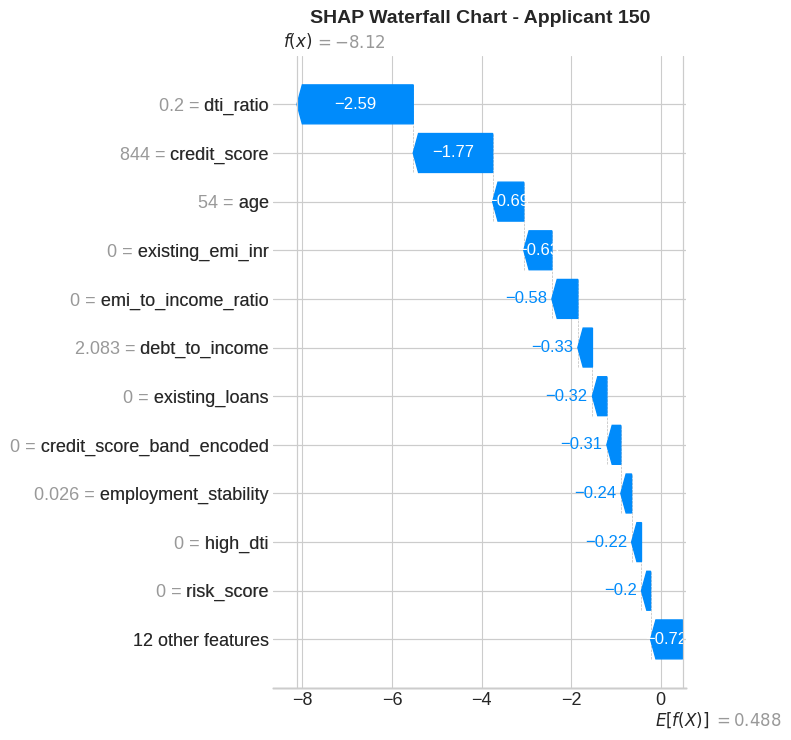

In [36]:
print(f"\nLOW RISK APPLICANT (Index: {low_risk_idx})")
print(f"   Default Probability: {y_test_pred_proba[low_risk_idx]:.2%}")
print(f"   Actual: {'Default' if y_test.iloc[low_risk_idx] == 1 else 'No Default'}")

fig = explain_prediction(low_risk_idx, X_test, shap_values, explainer, X_test.columns.tolist())
plt.savefig('shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()


RANDOM APPLICANT (Index: 180)
   Default Probability: 5.41%
   Actual: No Default


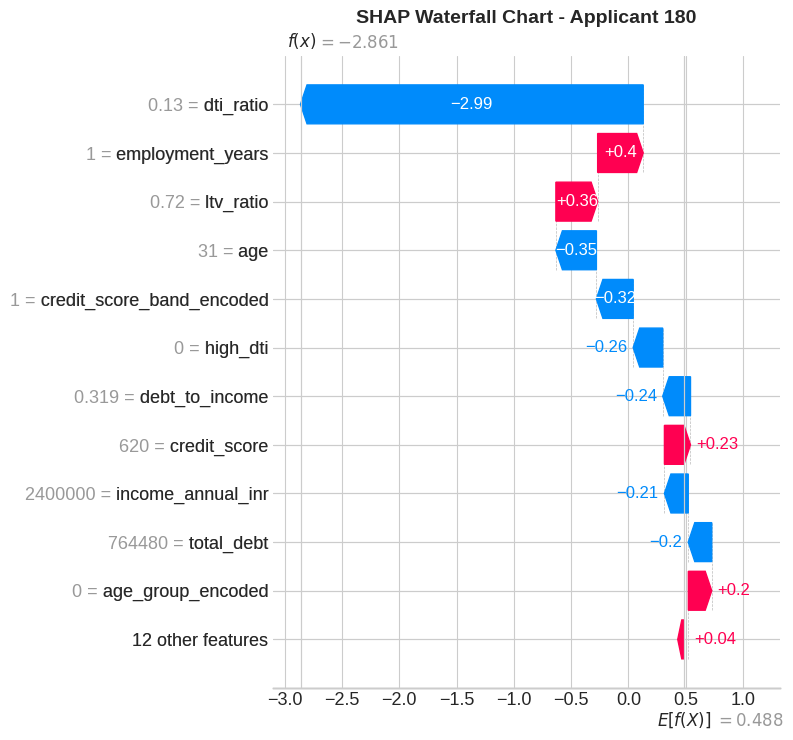

In [37]:
print(f"\nRANDOM APPLICANT (Index: {random_idx})")
print(f"   Default Probability: {y_test_pred_proba[random_idx]:.2%}")
print(f"   Actual: {'Default' if y_test.iloc[random_idx] == 1 else 'No Default'}")

fig = explain_prediction(random_idx, X_test, shap_values, explainer, X_test.columns.tolist())
plt.savefig('shap_waterfall_random.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.1 NEW: SHAP Force Plot (interactive HTML, saved to file)

In [38]:
# Force plots are the horizontal, compact cousin of the waterfall chart and are
# handy for embedding in a report or an internal web page.
shap.initjs()

force_html = shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
)
shap.save_html('shap_force_high_risk.html', force_html)
print("Saved interactive force plot to shap_force_high_risk.html")

# Force plot across the whole test set (useful to spot clusters of similar applicants)
force_html_all = shap.force_plot(
    explainer.expected_value,
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist()
)
shap.save_html('shap_force_all.html', force_html_all)
print("Saved full-test-set interactive force plot to shap_force_all.html")

Saved interactive force plot to shap_force_high_risk.html
Saved full-test-set interactive force plot to shap_force_all.html


## 12. Top 3 Risk Factors Function

In [39]:
def get_top_risk_factors(applicant_idx, X_data, shap_vals, feature_names, n=3):
    applicant_shap = shap_vals[applicant_idx]
    applicant_data = X_data.iloc[applicant_idx]

    factors = []
    for i, feature in enumerate(feature_names):
        factors.append({
            'feature': feature,
            'shap_value': applicant_shap[i],
            'feature_value': applicant_data[feature],
            'direction': 'increases risk' if applicant_shap[i] > 0 else 'decreases risk'
        })

    factors.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    return factors[:n]

In [40]:
print("=" * 60)
print("TOP 3 RISK FACTORS - HIGH RISK APPLICANT")
print("=" * 60)

top_factors = get_top_risk_factors(high_risk_idx, X_test, shap_values, X_test.columns.tolist())

for i, factor in enumerate(top_factors, 1):
    print(f"\n{i}. {factor['feature']}")
    print(f"   Value: {factor['feature_value']:.4f}")
    print(f"   SHAP Value: {factor['shap_value']:.4f}")
    print(f"   Impact: {factor['direction']}")

TOP 3 RISK FACTORS - HIGH RISK APPLICANT

1. dti_ratio
   Value: 2.9100
   SHAP Value: 3.1147
   Impact: increases risk

2. emi_to_income_ratio
   Value: 1.3119
   SHAP Value: 0.8537
   Impact: increases risk

3. total_debt
   Value: 5393588.0000
   SHAP Value: 0.4795
   Impact: increases risk


In [41]:
print("\n" + "=" * 60)
print("TOP 3 RISK FACTORS - LOW RISK APPLICANT")
print("=" * 60)

top_factors = get_top_risk_factors(low_risk_idx, X_test, shap_values, X_test.columns.tolist())

for i, factor in enumerate(top_factors, 1):
    print(f"\n{i}. {factor['feature']}")
    print(f"   Value: {factor['feature_value']:.4f}")
    print(f"   SHAP Value: {factor['shap_value']:.4f}")
    print(f"   Impact: {factor['direction']}")


TOP 3 RISK FACTORS - LOW RISK APPLICANT

1. dti_ratio
   Value: 0.2000
   SHAP Value: -2.5944
   Impact: decreases risk

2. credit_score
   Value: 844.0000
   SHAP Value: -1.7733
   Impact: decreases risk

3. age
   Value: 54.0000
   SHAP Value: -0.6943
   Impact: decreases risk


## 13. Score Band Assignment

In [43]:
def assign_score_band(probability):

    if probability < 0.3:
        return 'Low'

    elif probability < 0.6:
        return 'Medium'

    else:
        return 'High'


score_bands = [assign_score_band(p) for p in y_test_pred_proba]


results_df = pd.DataFrame({

    'actual_default': y_test.values,

    'predicted_probability': y_test_pred_proba,

    'predicted_default': y_test_pred,

    'score_band': score_bands

})


print("=" * 60)
print("SCORE BAND DISTRIBUTION (Test Set)")
print("=" * 60)

print(results_df['score_band'].value_counts())


print("\n" + "=" * 60)
print("DEFAULT RATE BY SCORE BAND")
print("=" * 60)

print(
    results_df
    .groupby('score_band')['actual_default']
    .agg(['mean', 'count'])
    .round(4)
)

SCORE BAND DISTRIBUTION (Test Set)
score_band
Low       151
High       41
Medium      8
Name: count, dtype: int64

DEFAULT RATE BY SCORE BAND
              mean  count
score_band               
High        0.7317     41
Low         0.0993    151
Medium      0.3750      8


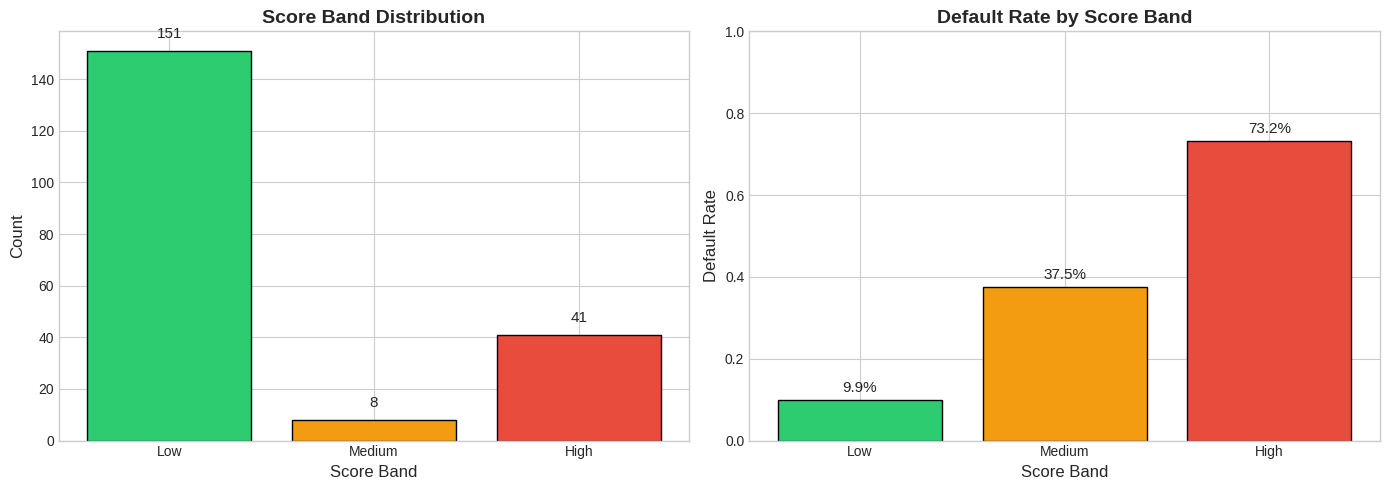

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_order = ['Low', 'Medium', 'High']
band_counts = results_df['score_band'].value_counts().reindex(band_order)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

ax = axes[0]
bars = ax.bar(band_counts.index, band_counts.values, color=colors, edgecolor='black')
ax.set_title('Score Band Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Score Band', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
for bar, count in zip(bars, band_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontsize=11)

default_rates = results_df.groupby('score_band')['actual_default'].mean().reindex(band_order)

ax = axes[1]
bars = ax.bar(default_rates.index, default_rates.values, color=colors, edgecolor='black')
ax.set_title('Default Rate by Score Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Score Band', fontsize=12)
ax.set_ylabel('Default Rate', fontsize=12)
ax.set_ylim(0, 1)
for bar, rate in zip(bars, default_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('score_bands.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.1 NEW: Score Band Funnel (Sankey-style approval funnel)

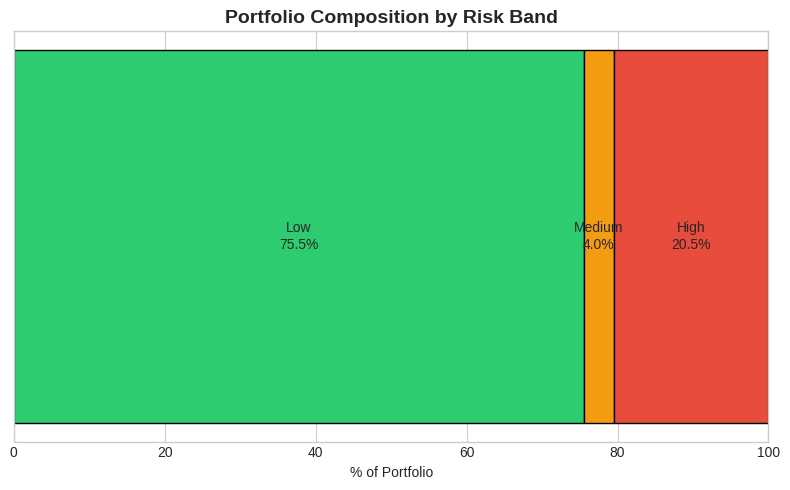

In [45]:
# A quick funnel view: how many applicants flow into each risk band, and what
# share of the *portfolio* each band represents.
fig, ax = plt.subplots(figsize=(8, 5))
band_pct = (band_counts / band_counts.sum() * 100).reindex(band_order)
left = 0
for band, pct, color in zip(band_order, band_pct, colors):
    ax.barh(0, pct, left=left, color=color, edgecolor='black', height=0.5,
            label=f'{band} ({pct:.1f}%)')
    ax.text(left + pct / 2, 0, f'{band}\n{pct:.1f}%', ha='center', va='center', fontsize=10)
    left += pct
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('% of Portfolio')
ax.set_title('Portfolio Composition by Risk Band', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('score_band_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Bias Audit

In [46]:
def bias_audit(df_original, y_true, y_pred_proba, y_pred, protected_col):
    results = []

    for group in df_original[protected_col].unique():
        mask = df_original[protected_col] == group
        group_y_true = y_true[mask]
        group_y_pred = y_pred[mask]
        group_proba = y_pred_proba[mask]

        if len(group_y_true) == 0:
            continue

        selection_rate = (group_y_pred == 0).mean()
        tpr = group_y_true[group_y_pred == 1].mean() if (group_y_pred == 1).sum() > 0 else 0
        fpr = 1 - group_y_true[group_y_pred == 0].mean() if (group_y_pred == 0).sum() > 0 else 0
        avg_prob = group_proba.mean()

        results.append({
            'group': group,
            'count': len(group_y_true),
            'default_rate': group_y_true.mean(),
            'approval_rate': selection_rate,
            'avg_probability': avg_prob,
            'tpr': tpr,
            'fpr': fpr
        })

    return pd.DataFrame(results)

In [48]:
df_test_original = df_fe.loc[X_test.index].copy()

print("=" * 60)
print("BIAS AUDIT - AGE GROUPS")
print("=" * 60)

age_audit = bias_audit(
    df_test_original,
    y_test.values,
    y_test_pred_proba,
    y_test_pred,
    'age_group'
)

print(age_audit.to_string(index=False))

dp_diff = age_audit['approval_rate'].max() - age_audit['approval_rate'].min()

print(f"\nDemographic Parity Difference (Age): {dp_diff:.4f}")

BIAS AUDIT - AGE GROUPS
       group  count  default_rate  approval_rate  avg_probability      tpr      fpr
Early Career     60      0.266667       0.766667         0.245286 0.714286 0.869565
       Young     50      0.260000       0.820000         0.181323 0.888889 0.878049
  Mid Career     50      0.200000       0.740000         0.290639 0.615385 0.945946
      Senior     40      0.225000       0.825000         0.193834 0.857143 0.909091

Demographic Parity Difference (Age): 0.0850


In [50]:
print("\n" + "=" * 60)
print("BIAS AUDIT - EMPLOYMENT TYPE")
print("=" * 60)

emp_audit = bias_audit(
    df_test_original,
    y_test.values,
    y_test_pred_proba,
    y_test_pred,
    'employment_type'
)

print(emp_audit.to_string(index=False))

dp_diff_emp = (
    emp_audit['approval_rate'].max()
    - emp_audit['approval_rate'].min()
)

print(f"\nDemographic Parity Difference (Employment): {dp_diff_emp:.4f}")


BIAS AUDIT - EMPLOYMENT TYPE
        group  count  default_rate  approval_rate  avg_probability      tpr      fpr
   government     59      0.322034       0.661017         0.351940 0.750000 0.897436
     salaried     42      0.285714       0.833333         0.185768 0.857143 0.828571
     contract     46      0.173913       0.782609         0.218997 0.600000 0.944444
self_employed     53      0.169811       0.886792         0.140152 0.833333 0.914894

Demographic Parity Difference (Employment): 0.2258


In [53]:
print("\n" + "=" * 60)
print("BIAS AUDIT - LOAN PURPOSE")
print("=" * 60)

purpose_audit = bias_audit(df_test_original, y_test.values, y_test_pred_proba, y_test_pred, 'loan_purpose')
print(purpose_audit.to_string(index=False))

dp_diff_purpose = purpose_audit['approval_rate'].max() - purpose_audit['approval_rate'].min()
print(f"\nDemographic Parity Difference (Loan Purpose): {dp_diff_purpose:.4f}")


BIAS AUDIT - LOAN PURPOSE
    group  count  default_rate  approval_rate  avg_probability      tpr      fpr
  vehicle     32      0.187500       0.812500         0.198896 0.666667 0.923077
  medical     23      0.391304       0.782609         0.242331 1.000000 0.777778
 business     29      0.241379       0.793103         0.216133 0.833333 0.913043
 personal     47      0.170213       0.829787         0.202898 0.625000 0.923077
     home     39      0.282051       0.769231         0.258033 0.888889 0.900000
education     30      0.233333       0.700000         0.275434 0.555556 0.904762

Demographic Parity Difference (Loan Purpose): 0.1298


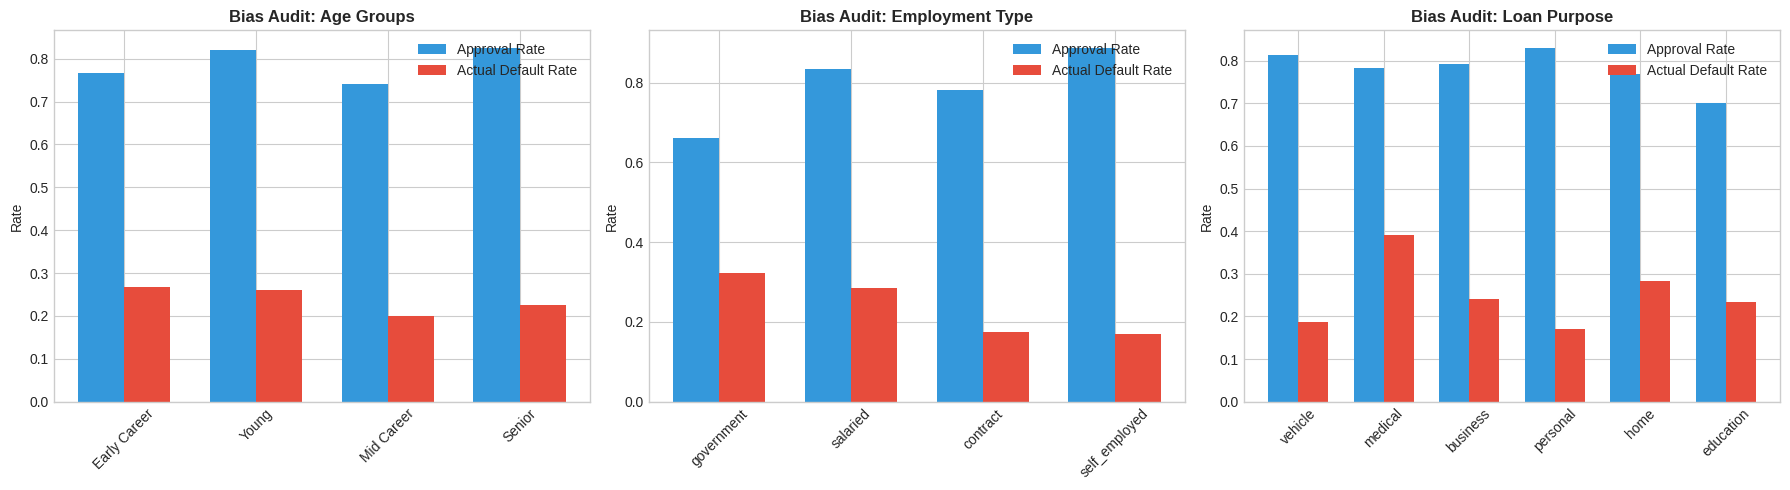

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(len(age_audit))
width = 0.35
ax.bar(x - width/2, age_audit['approval_rate'], width, label='Approval Rate', color='#3498db')
ax.bar(x + width/2, age_audit['default_rate'], width, label='Actual Default Rate', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(age_audit['group'], rotation=45)
ax.set_title('Bias Audit: Age Groups', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylabel('Rate')

ax = axes[1]
x = np.arange(len(emp_audit))
ax.bar(x - width/2, emp_audit['approval_rate'], width, label='Approval Rate', color='#3498db')
ax.bar(x + width/2, emp_audit['default_rate'], width, label='Actual Default Rate', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(emp_audit['group'], rotation=45)
ax.set_title('Bias Audit: Employment Type', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylabel('Rate')

ax = axes[2]
x = np.arange(len(purpose_audit))
ax.bar(x - width/2, purpose_audit['approval_rate'], width, label='Approval Rate', color='#3498db')
ax.bar(x + width/2, purpose_audit['default_rate'], width, label='Actual Default Rate', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(purpose_audit['group'], rotation=45)
ax.set_title('Bias Audit: Loan Purpose', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylabel('Rate')

plt.tight_layout()
plt.savefig('bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Save Model and Artifacts

In [55]:
import os
os.makedirs('artifacts', exist_ok=True)

model.save_model('artifacts/xgboost_model.json')
print("Model saved to artifacts/xgboost_model.json")

with open('artifacts/xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to artifacts/xgboost_model.pkl")

with open('artifacts/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("SHAP explainer saved to artifacts/shap_explainer.pkl")

with open('artifacts/feature_names.json', 'w') as f:
    json.dump(X.columns.tolist(), f)
print("Feature names saved to artifacts/feature_names.json")

with open('artifacts/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)
print("Label encoders saved to artifacts/label_encoders.pkl")

model_metadata = {
    'model_type': 'XGBoost',
    'version': '1.0',
    'training_date': datetime.now().isoformat(),
    'train_auc': float(train_auc),
    'test_auc': float(test_auc),
    'train_gini': float(train_gini),
    'test_gini': float(test_gini),
    'ks_statistic': float(ks_value),
    'n_features': X.shape[1],
    'feature_names': X.columns.tolist(),
    'hyperparameters': xgb_params,
    'acceptance_criteria_met': bool(test_gini >= 0.45)
}

with open('artifacts/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("Model metadata saved to artifacts/model_metadata.json")

Model saved to artifacts/xgboost_model.json
Model saved to artifacts/xgboost_model.pkl
SHAP explainer saved to artifacts/shap_explainer.pkl
Feature names saved to artifacts/feature_names.json
Label encoders saved to artifacts/label_encoders.pkl
Model metadata saved to artifacts/model_metadata.json


In [56]:
results_df.to_csv('artifacts/test_results.csv', index=False)
print("Test results saved to artifacts/test_results.csv")

age_audit.to_csv('artifacts/bias_audit_age.csv', index=False)
emp_audit.to_csv('artifacts/bias_audit_employment.csv', index=False)
purpose_audit.to_csv('artifacts/bias_audit_purpose.csv', index=False)
print("Bias audit results saved")

Test results saved to artifacts/test_results.csv
Bias audit results saved


## 16. Model Card

In [57]:
model_card = f"""
# FinWise Lending - Credit Risk Model Card

## Model Overview
- **Model Type**: XGBoost Classifier
- **Version**: 1.0
- **Training Date**: {datetime.now().strftime('%Y-%m-%d')}
- **Purpose**: Predict probability of loan default for credit risk assessment

## Performance Metrics

| Metric | Train | Test |
|--------|-------|------|
| AUC-ROC | {train_auc:.4f} | {test_auc:.4f} |
| Gini Coefficient | {train_gini:.4f} | {test_gini:.4f} |
| KS Statistic | - | {ks_value:.4f} |

### Acceptance Criteria
- [{'x' if test_gini >= 0.45 else ' '}] Gini coefficient >= 0.45 on test set (Achieved: {test_gini:.4f})

## Features Used
{chr(10).join([f'- {col}' for col in X.columns])}

## Limitations and Ethical Considerations
1. Model trained on historical data - may reflect historical biases
2. Should be used as a decision support tool, not sole decision maker
3. Regular monitoring for performance drift recommended
4. Bias audit performed across age groups, employment types, and loan purposes

## Bias Audit Summary
- **Age Groups**: Demographic parity difference = {dp_diff:.4f}
- **Employment Type**: Demographic parity difference = {dp_diff_emp:.4f}
- **Loan Purpose**: Demographic parity difference = {dp_diff_purpose:.4f}

## Intended Use
- Credit risk assessment for loan applications
- Decision support for loan officers
- NOT for automated decision-making without human oversight

## Contact
For questions about this model, contact the Data Science team.
"""

with open('artifacts/model_card.md', 'w') as f:
    f.write(model_card)

print("Model card saved to artifacts/model_card.md")
print("\n" + "=" * 60)
print("MODEL CARD PREVIEW")
print("=" * 60)
print(model_card)

Model card saved to artifacts/model_card.md

MODEL CARD PREVIEW

# FinWise Lending - Credit Risk Model Card

## Model Overview
- **Model Type**: XGBoost Classifier
- **Version**: 1.0
- **Training Date**: 2026-09-10
- **Purpose**: Predict probability of loan default for credit risk assessment

## Performance Metrics

| Metric | Train | Test |
|--------|-------|------|
| AUC-ROC | 1.0000 | 0.8842 |
| Gini Coefficient | 1.0000 | 0.7684 |
| KS Statistic | - | 0.6480 |

### Acceptance Criteria
- [x] Gini coefficient >= 0.45 on test set (Achieved: 0.7684)

## Features Used
- age
- income_annual_inr
- employment_years
- existing_loans
- existing_emi_inr
- credit_score
- loan_amount_inr
- ltv_ratio
- dti_ratio
- emi_to_income_ratio
- loan_to_income_ratio
- total_debt
- debt_to_income
- employment_stability
- high_dti
- high_ltv
- low_credit
- multiple_loans
- risk_score
- employment_type_encoded
- loan_purpose_encoded
- credit_score_band_encoded
- age_group_encoded

## Limitations and Ethical 

## 17. Project Summary

In [58]:
print("=" * 70)
print("FINWISE LENDING - CREDIT RISK SCORING PROJECT SUMMARY")
print("=" * 70)

print("\nDATA SUMMARY:")
print(f"   - Total applications: {len(df):,}")
print(f"   - Training samples: {len(X_train):,}")
print(f"   - Test samples: {len(X_test):,}")
print(f"   - Features used: {X.shape[1]}")

print("\nMODEL PERFORMANCE:")
print(f"   - Model: XGBoost Classifier")
print(f"   - Training AUC: {train_auc:.4f}")
print(f"   - Test AUC: {test_auc:.4f}")
print(f"   - Test Gini: {test_gini:.4f}")
print(f"   - KS Statistic: {ks_value:.4f}")
print(f"   - Acceptance Criteria (Gini >= 0.45): {'PASSED' if test_gini >= 0.45 else 'FAILED'}")

print("\nEXPLAINABILITY:")
print(f"   - SHAP TreeExplainer implemented")
print(f"   - Summary, dependence, waterfall and force plots generated")
print(f"   - Top 3 risk factors per application")

print("\nBIAS AUDIT:")
print(f"   - Age groups analyzed (Demographic Parity Diff: {dp_diff:.4f})")
print(f"   - Employment types analyzed (Demographic Parity Diff: {dp_diff_emp:.4f})")
print(f"   - Loan purposes analyzed (Demographic Parity Diff: {dp_diff_purpose:.4f})")

print("\nARTIFACTS SAVED:")
artifacts = [
    "xgboost_model.json - Trained model",
    "xgboost_model.pkl - Pickled model",
    "shap_explainer.pkl - SHAP explainer",
    "feature_names.json - Feature list",
    "label_encoders.pkl - Label encoders",
    "model_metadata.json - Model metadata",
    "model_card.md - Model documentation",
    "test_results.csv - Test predictions",
    "bias_audit_*.csv - Bias audit results",
]

for artifact in artifacts:
    print(f"   - {artifact}")

print("\n" + "=" * 70)
print("PROJECT COMPLETE!")
print("=" * 70)

FINWISE LENDING - CREDIT RISK SCORING PROJECT SUMMARY

DATA SUMMARY:
   - Total applications: 1,000
   - Training samples: 800
   - Test samples: 200
   - Features used: 23

MODEL PERFORMANCE:
   - Model: XGBoost Classifier
   - Training AUC: 1.0000
   - Test AUC: 0.8842
   - Test Gini: 0.7684
   - KS Statistic: 0.6480
   - Acceptance Criteria (Gini >= 0.45): PASSED

EXPLAINABILITY:
   - SHAP TreeExplainer implemented
   - Summary, dependence, waterfall and force plots generated
   - Top 3 risk factors per application

BIAS AUDIT:
   - Age groups analyzed (Demographic Parity Diff: 0.0850)
   - Employment types analyzed (Demographic Parity Diff: 0.2258)
   - Loan purposes analyzed (Demographic Parity Diff: 0.1298)

ARTIFACTS SAVED:
   - xgboost_model.json - Trained model
   - xgboost_model.pkl - Pickled model
   - shap_explainer.pkl - SHAP explainer
   - feature_names.json - Feature list
   - label_encoders.pkl - Label encoders
   - model_metadata.json - Model metadata
   - model_card.m